<a href="https://colab.research.google.com/github/saurav08750/Modeling-Qunatitative-Structural-Property-Relationship-Using-K-Nearest-Neighbors/blob/main/Modeling_Qunatitative_Structural_Property_Relationship_Using_K_Nearest_Neighbors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [110]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score,confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, ConfusionMatrixDisplay)
from sklearn.model_selection import LeaveOneOut
from tqdm.notebook import tqdm

In [111]:
df = pd.read_csv("https://raw.githubusercontent.com/edgarsmdn/MLCE_book/main/references/mutagenicity_kNN.csv")
df

,Unnamed: 0,Id,CAS,SMILES,Status,Experimental value,Predicted value,NumValenceElectrons,qed,TPSA,MolMR,BalabanJ,BertzCT,MolWt,MolLogP
0,0,1,100-00-5,O=[N+]([O-])c1ccc(cc1)Cl,Training,1,1,52,0.463602,43.14,38.1064,3.003401,244.429658,157.556,2.24820
1,1,2,100-01-6,O=[N+]([O-])c1ccc(N)cc1,Training,1,1,52,0.359544,69.16,37.5088,3.003401,242.429658,138.126,1.17700
2,2,3,100-02-7,O=[N+]([O-])c1ccc(O)cc1,Training,0,1,52,0.470728,63.37,34.7612,3.003401,241.674771,139.110,1.30040
3,3,4,100-11-8,O=[N+]([O-])c1ccc(cc1)CBr,Training,1,0,58,0.432586,43.14,45.7274,2.913802,257.648013,216.034,2.48970
4,4,5,100-12-9,O=[N+]([O-])c1ccc(cc1)CC,Training,0,0,58,0.479785,43.14,42.4744,2.913802,253.299498,151.165,2.15720
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5759,5759,5767,20395-16-8,O=C1N(C(=O)N(C(=O)N1CC=C)CC2OC2)CC=C,Training,1,0,102,0.485090,78.53,69.3560,2.668492,627.435628,265.269,-1.05750
5760,5760,5768,34718-47-3,O=C(C(Br)(Br)Br)Cl,Training,1,1,42,0.495987,17.07,40.3720,3.791118,85.425922,315.186,2.59030
5761,5761,5769,43204-63-3,N(CCBr)CCBr,Training,1,1,44,0.568556,12.03,40.4577,2.447473,28.870765,230.931,1.36580
5762,5762,5770,52583-35-4,N#Cc2cc(cc(c2(N=Nc1ccc(cc1(NC(=O)C))N(CCOC)CCO...,Training,1,1,184,0.264581,185.59,125.3525,2.552977,1169.342047,485.457,3.84768


In [112]:
df["Experimental value"]

,Experimental value
0,1
1,1
2,0
3,1
4,0
...,...
5759,1
5760,1
5761,1
5762,1


In [113]:
df.head(1)

,Unnamed: 0,Id,CAS,SMILES,Status,Experimental value,Predicted value,NumValenceElectrons,qed,TPSA,MolMR,BalabanJ,BertzCT,MolWt,MolLogP
0,0,1,100-00-5,O=[N+]([O-])c1ccc(cc1)Cl,Training,1,1,52,0.463602,43.14,38.1064,3.003401,244.429658,157.556,2.2482


In [114]:
df_clean = df.drop(["Unnamed: 0",	"Id",	"CAS",	"SMILES"	,"Status"	,"Experimental value",	"Predicted value"	],axis=1)

In [115]:
X = df_clean

In [116]:
x = df_clean.iloc[:,0]
Y = df_clean.iloc[:,1]
c = df_clean.iloc[:,2]
s = df_clean.iloc[:,3]

In [117]:
x, Y

(0        52
 1        52
 2        52
 3        58
 4        58
        ... 
 5759    102
 5760     42
 5761     44
 5762    184
 5763     88
 Name: NumValenceElectrons, Length: 5764, dtype: int64,
 0       0.463602
 1       0.359544
 2       0.470728
 3       0.432586
 4       0.479785
           ...   
 5759    0.485090
 5760    0.495987
 5761    0.568556
 5762    0.264581
 5763    0.735392
 Name: qed, Length: 5764, dtype: float64)

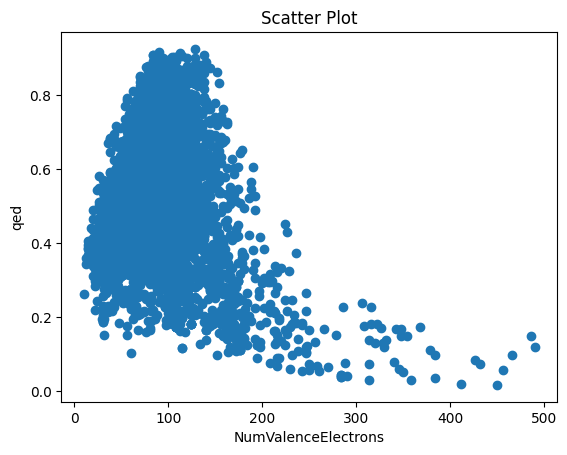

In [118]:
plt.scatter(x,Y)
plt.xlabel("NumValenceElectrons")
plt.ylabel("qed")
plt.title("Scatter Plot")
plt.show()

In [119]:
df_clean.dropna()

,NumValenceElectrons,qed,TPSA,MolMR,BalabanJ,BertzCT,MolWt,MolLogP
0,52,0.463602,43.14,38.1064,3.003401,244.429658,157.556,2.24820
1,52,0.359544,69.16,37.5088,3.003401,242.429658,138.126,1.17700
2,52,0.470728,63.37,34.7612,3.003401,241.674771,139.110,1.30040
3,58,0.432586,43.14,45.7274,2.913802,257.648013,216.034,2.48970
4,58,0.479785,43.14,42.4744,2.913802,253.299498,151.165,2.15720
...,...,...,...,...,...,...,...,...
5759,102,0.485090,78.53,69.3560,2.668492,627.435628,265.269,-1.05750
5760,42,0.495987,17.07,40.3720,3.791118,85.425922,315.186,2.59030
5761,44,0.568556,12.03,40.4577,2.447473,28.870765,230.931,1.36580
5762,184,0.264581,185.59,125.3525,2.552977,1169.342047,485.457,3.84768


In [120]:
df_clean.dtypes

,0
NumValenceElectrons,int64
qed,float64
TPSA,float64
MolMR,float64
BalabanJ,float64
BertzCT,float64
MolWt,float64
MolLogP,float64


In [121]:
df_clean[df_clean["NumValenceElectrons"]==490]

,NumValenceElectrons,qed,TPSA,MolMR,BalabanJ,BertzCT,MolWt,MolLogP
3311,490,0.117861,359.98,325.4772,1.320824,3416.975083,1255.438,0.72564


In [122]:
df_clean[df_clean["NumValenceElectrons"]==10]

,NumValenceElectrons,qed,TPSA,MolMR,BalabanJ,BertzCT,MolWt,MolLogP
1080,10,0.262188,19.9,3.9295,3.0,6.754888,28.01,-0.03751


In [123]:
df_clean[df_clean["NumValenceElectrons"].notnull()]

,NumValenceElectrons,qed,TPSA,MolMR,BalabanJ,BertzCT,MolWt,MolLogP
0,52,0.463602,43.14,38.1064,3.003401,244.429658,157.556,2.24820
1,52,0.359544,69.16,37.5088,3.003401,242.429658,138.126,1.17700
2,52,0.470728,63.37,34.7612,3.003401,241.674771,139.110,1.30040
3,58,0.432586,43.14,45.7274,2.913802,257.648013,216.034,2.48970
4,58,0.479785,43.14,42.4744,2.913802,253.299498,151.165,2.15720
...,...,...,...,...,...,...,...,...
5759,102,0.485090,78.53,69.3560,2.668492,627.435628,265.269,-1.05750
5760,42,0.495987,17.07,40.3720,3.791118,85.425922,315.186,2.59030
5761,44,0.568556,12.03,40.4577,2.447473,28.870765,230.931,1.36580
5762,184,0.264581,185.59,125.3525,2.552977,1169.342047,485.457,3.84768


In [124]:
df.iloc[:,:3]

,Unnamed: 0,Id,CAS
0,0,1,100-00-5
1,1,2,100-01-6
2,2,3,100-02-7
3,3,4,100-11-8
4,4,5,100-12-9
...,...,...,...
5759,5759,5767,20395-16-8
5760,5760,5768,34718-47-3
5761,5761,5769,43204-63-3
5762,5762,5770,52583-35-4


In [125]:
df[df["Predicted value"]=="Non Predicted"].index

Index([1844, 2194, 4118, 4180, 5633, 5655], dtype='int64')

In [126]:
df_drop = df.drop(df[df["Predicted value"]=="Non Predicted"].index)

In [127]:
df_clean

,NumValenceElectrons,qed,TPSA,MolMR,BalabanJ,BertzCT,MolWt,MolLogP
0,52,0.463602,43.14,38.1064,3.003401,244.429658,157.556,2.24820
1,52,0.359544,69.16,37.5088,3.003401,242.429658,138.126,1.17700
2,52,0.470728,63.37,34.7612,3.003401,241.674771,139.110,1.30040
3,58,0.432586,43.14,45.7274,2.913802,257.648013,216.034,2.48970
4,58,0.479785,43.14,42.4744,2.913802,253.299498,151.165,2.15720
...,...,...,...,...,...,...,...,...
5759,102,0.485090,78.53,69.3560,2.668492,627.435628,265.269,-1.05750
5760,42,0.495987,17.07,40.3720,3.791118,85.425922,315.186,2.59030
5761,44,0.568556,12.03,40.4577,2.447473,28.870765,230.931,1.36580
5762,184,0.264581,185.59,125.3525,2.552977,1169.342047,485.457,3.84768


In [128]:
y = df["Experimental value"].astype(int)
y

,Experimental value
0,1
1,1
2,0
3,1
4,0
...,...
5759,1
5760,1
5761,1
5762,1


In [129]:
Mutagenic = int((y.sum()/len(y))*100)
Non_Mutagenic = 100 - Mutagenic
print(f'Percentage of Mutagenic compound:{Mutagenic}')
print(f'Percentage of Non Mutagenic compound:{Non_Mutagenic}')

Percentage of Mutagenic compound:56
Percentage of Non Mutagenic compound:44


In [130]:
x_train, x_test, y_train, y_test = train_test_split(X , y , test_size=0.2 , random_state=0)

In [131]:
len(x_train), len(x_test)

(4611, 1153)

In [132]:
int(y_train.sum()), int(len(y_train) - y_train.sum()), int(y_test.sum()), int(len(y_test) - y_test.sum())

(2607, 2004, 644, 509)

In [133]:

scaler = StandardScaler()

In [134]:
scaler.fit(x_train)
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [135]:
x_train_scaled, x_test_scaled

(array([[ 2.12388901, -0.83189648,  1.47063519, ...,  1.66261095,
          2.59159212,  0.46980319],
        [ 1.37684535, -0.48094159, -1.10859929, ...,  0.65179722,
          1.13212837,  2.14274244],
        [ 2.2639597 , -2.34185166,  2.37715612, ...,  4.37012723,
          2.26927857,  1.29701729],
        ...,
        [ 0.30297007,  2.02079433,  0.35432342, ...,  0.69583677,
          0.67184179, -0.25015872],
        [ 0.25627984,  0.41726181,  0.19107481, ...,  0.90036826,
          0.19863991,  0.43622211],
        [-1.37787818,  0.18017205, -0.70375209, ..., -1.23541796,
         -0.36555537, -0.49353868]]),
 array([[ 1.65698672,  1.30330086,  0.48459488, ...,  0.33029692,
          1.2873879 ,  1.09234886],
        [-0.67752474,  0.94859064, -0.20231224, ..., -0.69094668,
         -0.621068  , -0.98750195],
        [-0.21062245, -1.19651722, -0.49606618, ..., -1.09156035,
         -0.47372319,  0.40004989],
        ...,
        [ 0.44304076, -1.22099156, -0.95868187, ...,  

In [136]:
scaler.mean_

array([8.70221210e+01, 5.13332348e-01, 5.38802386e+01, 6.50020038e+01,
       2.57253915e+00, 5.19765923e+02, 2.41244465e+02, 2.57824068e+00])

In [137]:
scaler.scale_

array([4.28355146e+01, 1.66527409e-01, 4.27568726e+01, 3.08447128e+01,
       6.36481227e-01, 3.77691942e+02, 1.15986437e+02, 1.92965764e+00])

In [138]:
knn = KNeighborsClassifier(n_neighbors=3)

In [139]:
knn.fit(x_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=3)

In [140]:
y_pred = knn.predict(x_test_scaled)

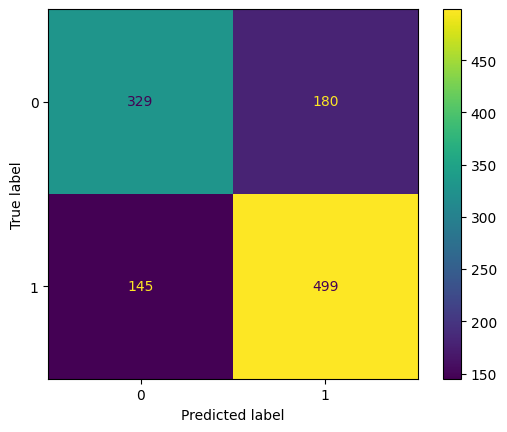

In [141]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [142]:
print(f'Accuracy Score: {accuracy_score(y_test, y_pred)}')
print(f'Precision Score: {precision_score(y_test, y_pred)}')
print(f'F1-Score: {f1_score(y_test, y_pred)}')

Accuracy Score: 0.7181266261925412
Precision Score: 0.7349042709867453
F1-Score: 0.7543461829176115


In [143]:
np.zeros(df_clean.shape[0])

array([0., 0., 0., ..., 0., 0., 0.])

In [144]:
L = LeaveOneOut()
print(f'Number of splits : {L.get_n_splits(X)}')

Number of splits : 5764


In [174]:
all_y_test = []
all_y_pred = []

for (train_index, test_index) in L.split(X):
  x_train_L = X.iloc[train_index]
  y_train_L = y.iloc[train_index]
  x_test_L = X.iloc[test_index]
  y_test_L = y.iloc[test_index]

  knn_L = KNeighborsClassifier(n_neighbors=4)
  knn_L.fit(x_train_L, y_train_L)
  y_pred_L = knn_L.predict(x_test_L)

  all_y_test.extend(y_test_L)
  all_y_pred.extend(y_pred_L)

Accuracy Score: 0.6380985426786954
Precision Score: 0.7166232800297508
F1-Score: 0.6488215488215489


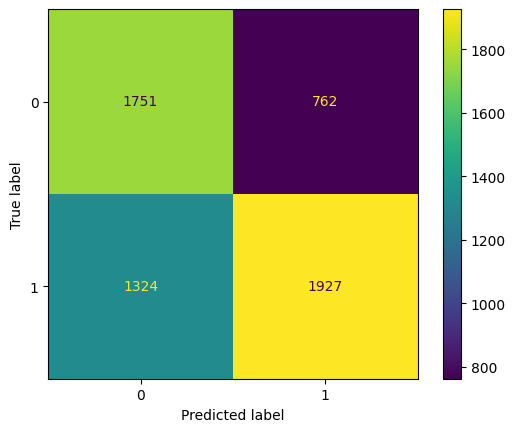

In [175]:
print(f'Accuracy Score: {accuracy_score(all_y_test, all_y_pred)}')
print(f'Precision Score: {precision_score(all_y_test, all_y_pred)}')
print(f'F1-Score: {f1_score(all_y_test, all_y_pred)}')
cm_L = confusion_matrix(all_y_test, all_y_pred)
disp_L = ConfusionMatrixDisplay(confusion_matrix=cm_L)
disp_L.plot()

In [147]:
hyp_K = np.arange(1,100,2).astype(int)
x_train_hyp, x_validation, y_train_hyp, y_validation = train_test_split(x_train_scaled, y_train, test_size=0.1, random_state=0)

train_misclassification = []
validation_misclassification = []

for i in tqdm(range(len(hyp_K))):
  knn_hyp = KNeighborsClassifier(n_neighbors= hyp_K[i])
  knn_hyp.fit(x_train_hyp, y_train_hyp)
  y_pred_train = knn_hyp.predict(x_train_hyp)
  y_pred_validation = knn_hyp.predict(x_validation)
  train_misclassification.append(1 - accuracy_score(y_train_hyp, y_pred_train))
  validation_misclassification.append(1 - accuracy_score(y_validation, y_pred_validation))

  0%|          | 0/50 [00:00<?, ?it/s]

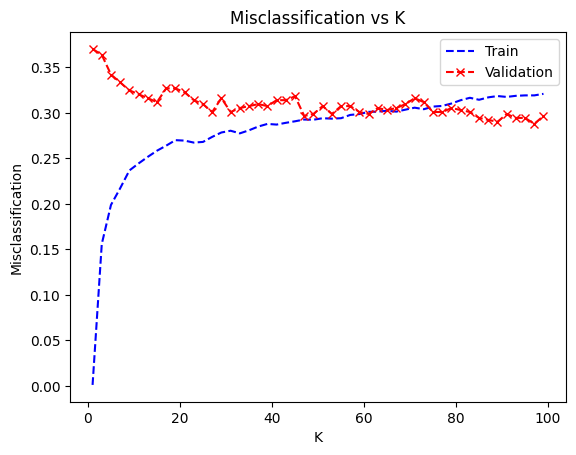

In [179]:
plt.figure()
plt.plot(hyp_K, train_misclassification,'b--')
plt.plot(hyp_K, validation_misclassification, 'rx--')
plt.plot()
plt.xlabel("K")
plt.ylabel("Misclassification")
plt.title("Misclassification vs K")
plt.legend(["Train", "Validation"])
plt.show()

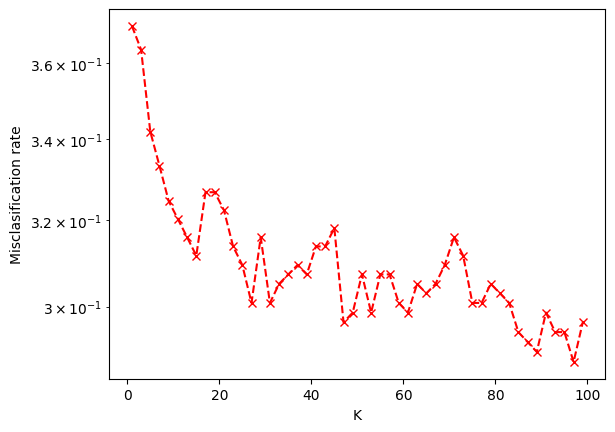

In [182]:
plt.figure()
plt.plot(hyp_K, validation_misclassification, 'rx--', label='Validation')
plt.yscale('log')
plt.xlabel('K')
plt.ylabel('Misclasification rate')
plt.show()